---
title: "STATS 531 project report format\\vspace{-2cm}"
bibliography: references.bib
output: pdf_document
format:
  pdf:
    include-in-header:
      text: |
        \RedeclareSectionCommand[
          beforeskip=0.5em,
          runin=false,
          afterskip=0em
        ]{section}
        \RedeclareSectionCommand[
          beforeskip=0em,
          runin=false,
          afterskip=0em
        ]{subsection}
        \RedeclareSectionCommand[
          beforeskip=0em,
          runin=false,
          afterskip=0em
        ]{subsubsection}
        \usepackage{fullpage}
number-sections: true
jupyter: python3
---



In [18]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [19]:
#DETROIT CRIME DATASET
import pandas as pd
crime = pd.read_csv("rms_crime_incidents.csv", comment='#')

crime.head()


C:\Users\enora\AppData\Local\Temp\ipykernel_20708\2156651975.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv("rms_crime_incidents.csv", comment='#')


,X,Y,incident_entry_id,nearest_intersection,offense_category,offense_description,state_offense_code,arrest_charge,charge_description,incident_occurred_at,...,report_number,scout_car_area,police_precinct,census_block_2020_geoid,neighborhood,council_district,zip_code,longitude,latitude,ESRI_OID
0,-83.241300,42.374040,1255424-2307,Wadsworth St & Fielding St,LARCENY,LARCENY - OTHER ...,2307,23007,LARCENY - OTHER ...,2025/03/11 04:00:00+00,...,2503170044,0603,06,2.616355e+14,Weatherby,7.0,48228.0,-83.241300,42.374040,1.0
1,-83.147703,42.340357,1380965-2601,McDonald St & Radcliffe St,FRAUD,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2601,26001,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2025/12/17 17:30:00+00,...,2601020174,0401,04,2.616353e+14,Claytown,6.0,48210.0,-83.147703,42.340357,2.0
2,-83.114223,42.357153,1389365-2900,Seebaldt St & Turner St,DAMAGE TO PROPERTY,DAMAGE TO PROPERTY ...,2900,29000,DAMAGE TO PROPERTY ...,2026/01/27 12:06:00+00,...,2601270059,1006,10,2.616353e+14,Midwest,6.0,48204.0,-83.114223,42.357153,3.0
3,-83.043401,42.424733,1363733-5701,Iowa St & Minnesota St,INVASION OF PRIVACY -OTHER,TRESPASS,5701,57001,TRESPASS,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,4.0
4,-83.043401,42.424733,1363732-1301,Iowa St & Minnesota St,ASSAULT,ASSAULT AND BATTERY/SIMPLE ASSAULT,1301,13001,ASSAULT AND BATTERY/SIMPLE ASSAULT,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,5.0


In [20]:
#crime["date"] = pd.to_datetime(crime["date"], utc=True)
#list(crime.columns)
crime['incident_occurred_at'].head()

crime["date"] = pd.to_datetime(
    crime["incident_occurred_at"],
    utc=True
)

crime_ts = crime[
    (crime["incident_occurred_at"] >= "2017-01-01") &
    (crime["incident_occurred_at"] <  "2026-01-01")
]


monthly_counts = (
    crime_ts
    .set_index("date")
    .resample("MS")         # Month Start
    .size()
    .rename("crime_count")
    .reset_index()
)

print("Monthly points:", len(monthly_counts))

Monthly points: 108


In [21]:
print(crime['date'].min())
monthly_counts.head()

1915-10-17 01:00:00+00:00


,date,crime_count
0,2017-01-01 00:00:00+00:00,6399
1,2017-02-01 00:00:00+00:00,5900
2,2017-03-01 00:00:00+00:00,6691
3,2017-04-01 00:00:00+00:00,6958
4,2017-05-01 00:00:00+00:00,7431


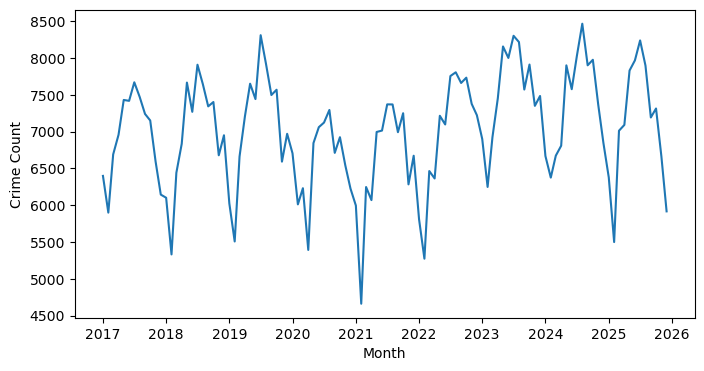

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(monthly_counts['date'], monthly_counts['crime_count'])
plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()


In [23]:
crime_ts["year"] = crime_ts["date"].dt.year

crime_ts.groupby("year").size()

C:\Users\enora\AppData\Local\Temp\ipykernel_20708\3040918361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_ts["year"] = crime_ts["date"].dt.year


year
2017    83075
2018    83580
2019    85359
2020    79073
2021    78929
2022    83788
2023    90530
2024    88601
2025    85008
dtype: int64

In [24]:
monthly_counts["crime_count"].describe()

count     108.000000
mean     7017.990741
std       757.812105
min      4662.000000
25%      6580.250000
50%      7095.000000
75%      7570.750000
max      8467.000000
Name: crime_count, dtype: float64

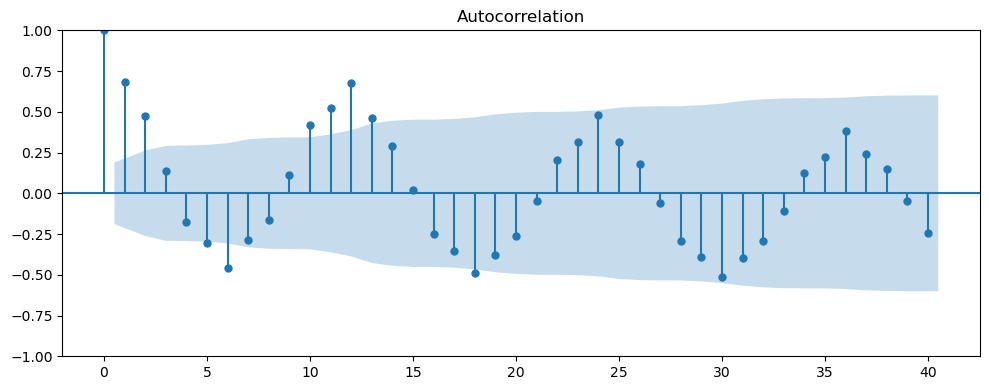

In [25]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_counts['crime_count'], ax=ax, lags=40)
plt.tight_layout()
plt.show()


Definitely seems like the crime data will work- ARMA model will fail because of seasonality shown clearly in the acf plots, but we can do another model that properly accounts for seasonality and explain why this correction is needed.

<Axes: >

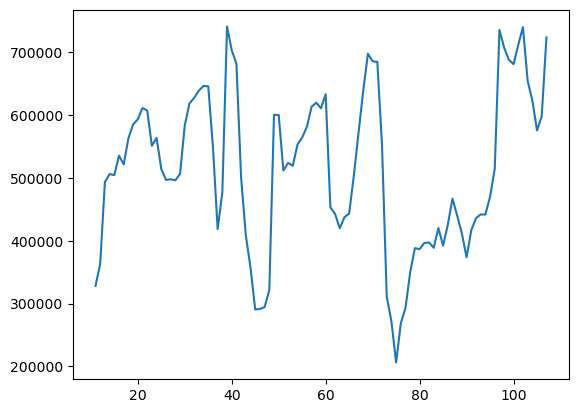

In [26]:
monthly_counts["crime_count"].rolling(12).var().plot()

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts["covid"] = np.select(
    [
        monthly_counts["date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts["date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts["date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts["date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts["covid"] = pd.Categorical(
    monthly_counts["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)



In [28]:
X = pd.get_dummies(monthly_counts["covid"], drop_first=True).astype(float)

In [29]:
X.isna().sum()

during    0
post      0
dtype: int64

In [30]:
monthly_counts[monthly_counts["crime_count"].isna()].head(10)

,date,crime_count,covid


In [31]:
#model without seasonal terms
fit1 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(0,0,0,12), trend='c', exog=X).fit()

print(fit1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    108.7786    100.404      1.083      0.279     -88.009     305.566
during      5287.2183    500.241     10.569      0.000    4306.764    6267.672
post        7276.6973    687.819     10.579      0.000    5928.597    8624.797
ar.L1          0.9689      0.025     38.405      0.000       0.919       1.018
ma.L1          0.0437      0.102      0.428      0.668      -0.156       0.243
sigma2      4.428e+05   8.39e+04      5.279      0.000    2.78e+05    6.07e+05


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [32]:
#considering several possible models with different non-seasonal and seasonal AR/MA lags

#1 AR, 0 MA in both seasonal and non seasonal
fit1 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 0), seasonal_order=(1,0,0,12), trend='c', exog=X).fit()
print(fit1.aic)

#0 AR, 1 MA in both seasonal and non seasonal
fit2 =SARIMAX(monthly_counts['crime_count'],order=(0,0, 1), seasonal_order=(0,0,1,12), trend='c', exog=X).fit()
print(fit2.aic)

#1 AR, 1 MA in both seasonal and non seasonal
fit3 =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(1,0,1,12), trend='c', exog=X).fit()
print(fit3.aic)

#2 AR, 1 MA in both seasonal and non seasonal
fit4 =SARIMAX(monthly_counts['crime_count'],order=(2,0, 1), seasonal_order=(2,0,1,12), trend='c', exog=X).fit()
print(fit4.aic)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1767.6261618339724


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1885.3757787126945


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1774.8163285165876
1776.538593957242


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [33]:
#first model fit seems to be the best (1 AR, 0 MA in both seasonal and non seasonal)
print(fit1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    131.6733     97.285      1.353      0.176     -59.001     322.348
during      5792.7589    591.957      9.786      0.000    4632.545    6952.973
post        7315.9087    811.676      9.013      0.000    5725.052    8906.765
ar.L1          0.9577      0.029     33.377      0.000       0.901       1.014
ar.S.L12       0.1111      0.053      2.097      0.036       0.007       0.215
sigma2      4.872e+05   1.04e+05      4.677      0.000    2.83e+05    6.91e+05


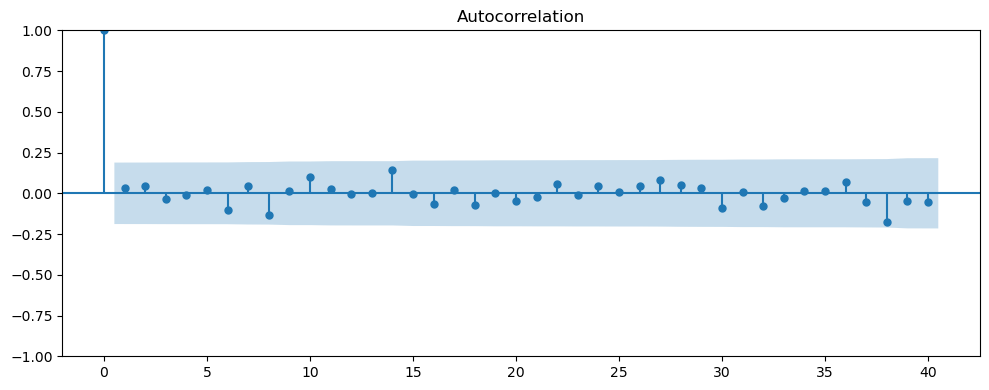

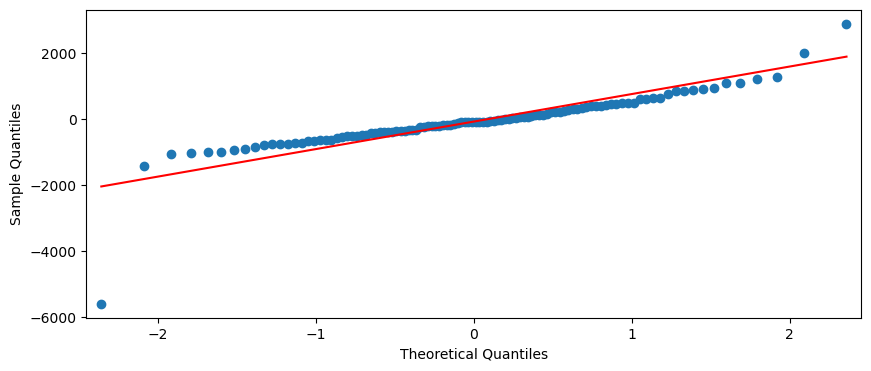

In [34]:
import statsmodels.api as sm
import pylab as py

#ACF of the residuals
resids1 = fit1.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids1, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids1, line='s', ax=ax)
plt.show()

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


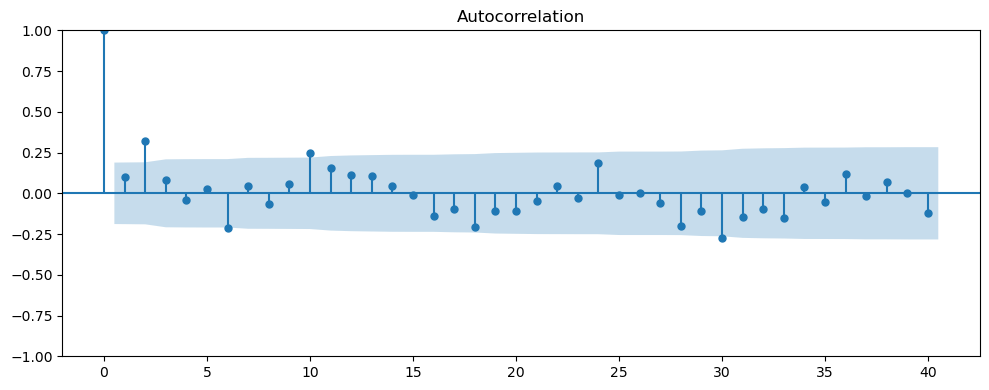

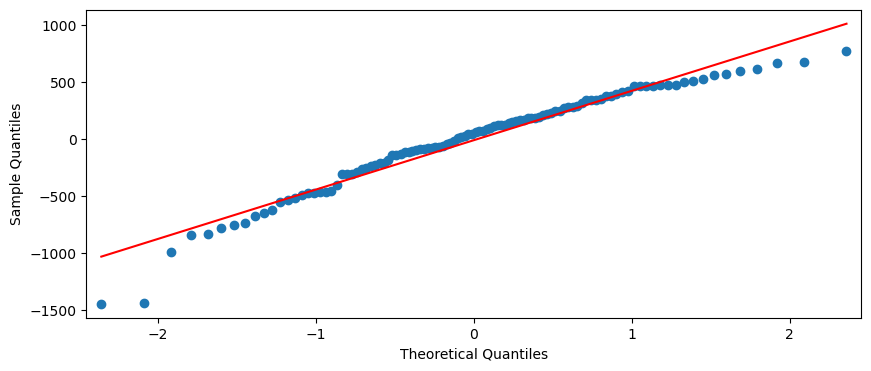

In [35]:
#MODEL WITHOUT COVID AS EXOGENOUS VAR, SHOWS WORSE FIT. INDICATES ADDING COVID VAR HELPED
fit1_nocov =SARIMAX(monthly_counts['crime_count'],order=(1,0, 1), seasonal_order=(1,0,0,12), trend='c').fit()

resids1_nocov = fit1_nocov.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids1_nocov, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids1_nocov, line='s', ax=ax)
plt.show()

In [36]:
#NOW LOOKING AT UNEMPLOYMENT DATA
from datetime import datetime
unemploy = pd.read_csv("unemployment_wayne_county.csv")
print(unemploy.head())

unemploy = unemploy[unemploy['Year'] >= 2016]

#unemploy["Date"] = pd.to_datetime(unemploy["Label"], format="%Y %b")
#unemploy['Value'] = pd.to_numeric(unemploy['Value'], errors='coerce')

unemploy["date"] = pd.to_datetime(unemploy["Label"], format="%Y %b")

              Series ID  Year Period     Label Value
0  LAUCN261630000000003  2010    M01  2010 Jan  17.1
1  LAUCN261630000000003  2010    M02  2010 Feb  16.8
2  LAUCN261630000000003  2010    M03  2010 Mar  16.9
3  LAUCN261630000000003  2010    M04  2010 Apr  16.0
4  LAUCN261630000000003  2010    M05  2010 May  15.6


In [37]:

unemploy_ts = unemploy.loc[
    (unemploy['date'] >= '2017-01-01') & 
    (unemploy['date'] < '2026-01-01')
].copy()

unemploy_ts["Value"] = pd.to_numeric(unemploy_ts["Value"], errors="coerce")

monthly_unemploy = (
    unemploy_ts
    .set_index("date")['Value']
    .resample("MS")
    .mean()
    .rename("unemploy_rate")
    .reset_index()
)


In [38]:
monthly_unemploy[monthly_unemploy["unemploy_rate"].isna()].head(10)

,date,unemploy_rate
105,2025-10-01,NaN


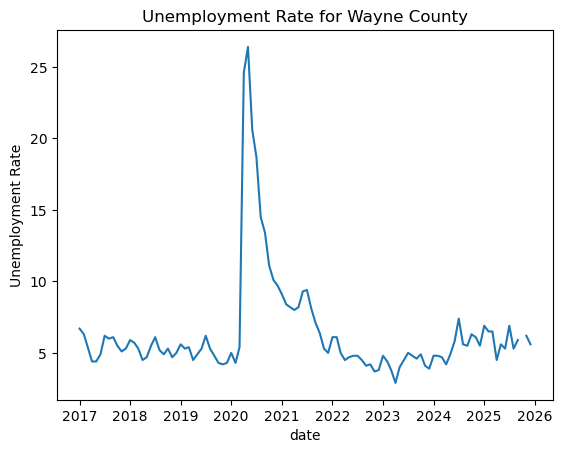

In [39]:
plt.plot(monthly_unemploy["date"], monthly_unemploy["unemploy_rate"])
plt.xlabel("date")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate for Wayne County")

plt.show()

In [40]:


monthly_unemploy.loc[monthly_unemploy["unemploy_rate"].isna(), ["unemploy_rate"]]
#so number 105 is missing 
print(monthly_unemploy.at[105, 'date'])

monthly_unemploy.at[105, "unemploy_rate"] = (monthly_unemploy.at[104, "unemploy_rate"] + monthly_unemploy.at[106, "unemploy_rate"]) / 2
print(monthly_unemploy.at[105, "unemploy_rate"])


2025-10-01 00:00:00
6.050000000000001


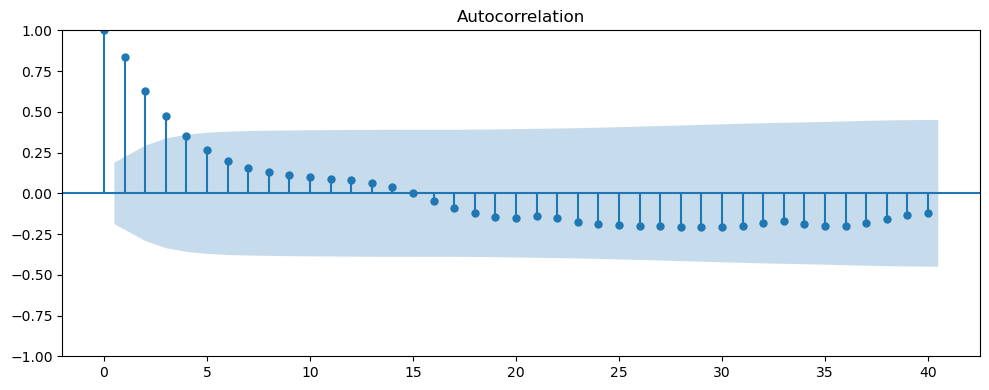

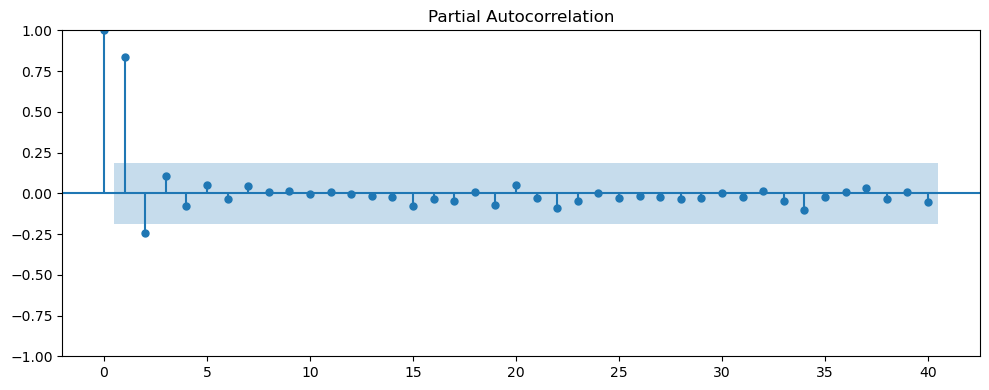

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
plt.tight_layout()
plt.show()

In [42]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_unemploy["covid"] = np.select(
    [
        monthly_unemploy["date"] < pd.Timestamp("2020-03-01"),
        (monthly_unemploy["date"] >= pd.Timestamp("2020-03-01")) & (monthly_unemploy["date"] < pd.Timestamp("2022-07-01")),
        monthly_unemploy["date"] >= pd.Timestamp("2022-07-01"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_unemploy["covid"] = pd.Categorical(
    monthly_unemploy["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

In [43]:
# monthly_unemploy = monthly_unemploy.sort_index()
monthly_unemploy = monthly_unemploy.sort_values("date").set_index("date")
# monthly_unemploy = monthly_unemploy.asfreq("MS")
monthly_unemploy["covid"] = monthly_unemploy["covid"].ffill()

In [44]:
X = pd.get_dummies(monthly_unemploy["covid"], drop_first=True).astype(float)

In [45]:
df_model = pd.concat([monthly_unemploy["unemploy_rate"].rename("y"), X], axis=1).dropna()
y = df_model["y"]
X = df_model.drop(columns="y")

In [46]:
#https://www.geeksforgeeks.org/artificial-intelligence/what-is-an-arimax-model/
#fit5 =SARIMAX(monthly_unemploy["unemploy_rate"],order=(1,0, 1), trend='c', exog = X).fit()
fit5 = SARIMAX(y, order=(1,0,1), trend="c", exog=X).fit()
print(fit5.aic)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


462.38820727494567


In [47]:
 print(fit5.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8806      1.549      1.214      0.225      -1.156       4.917
during        -3.9805      0.895     -4.445      0.000      -5.736      -2.225
post          -3.8611      5.444     -0.709      0.478     -14.531       6.809
ar.L1          0.7876      0.121      6.531      0.000       0.551       1.024
ma.L1          0.4972      0.157      3.158      0.002       0.189       0.806
sigma2         3.7235      0.446      8.358      0.000       2.850       4.597


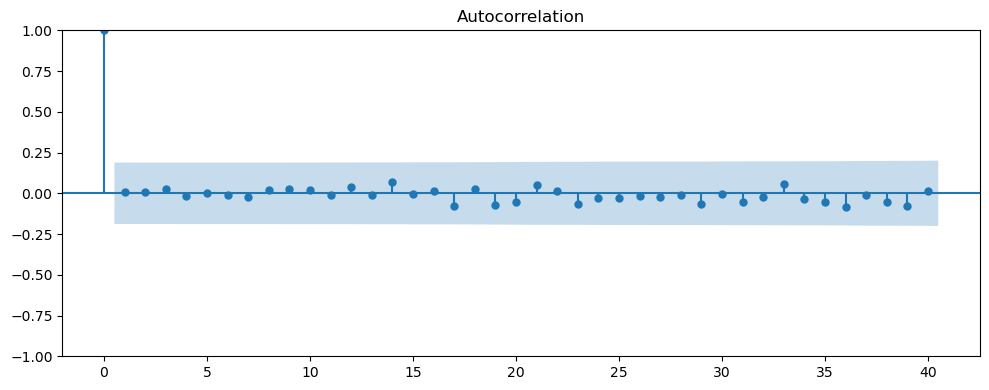

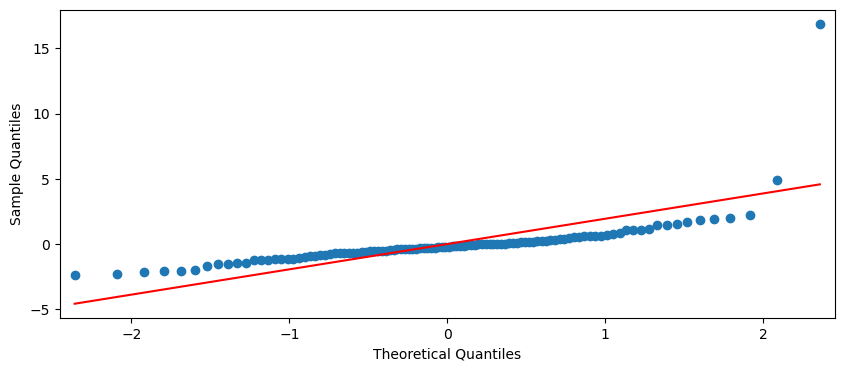

In [48]:
resids5 = fit5.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids5, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids5, line='s', ax=ax)
plt.show()

In [49]:
#FIT SAME MODEL BUT LOG OF UNEMPLOYMENT TO TRY TO IMRPOVE QQ PLOT/NORMALITY OF RESIDUALS
fit6 = SARIMAX(np.log(y), order=(1,0,1), trend="c", exog=X).fit()
print(fit6.aic)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


-42.11063824869801


C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


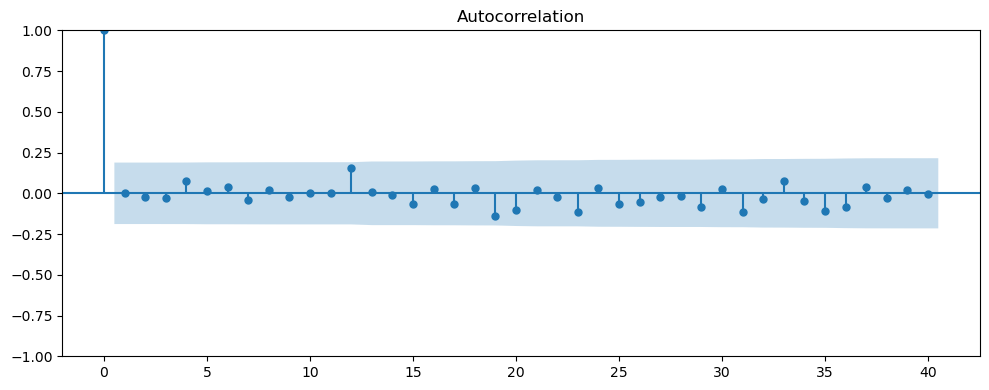

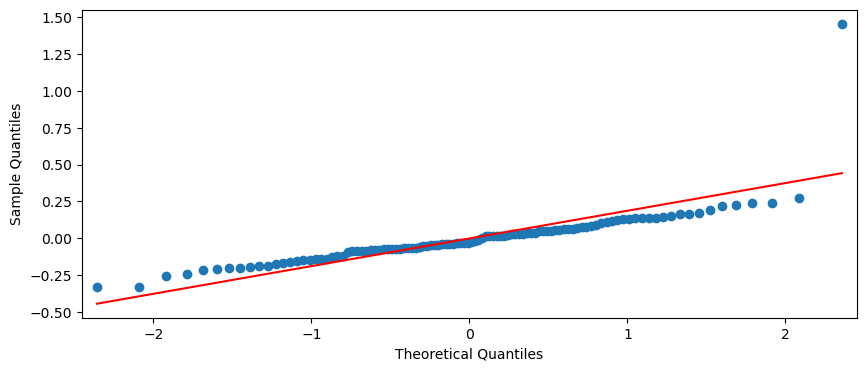

In [50]:
resids6 = fit6.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids6, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids6, line='s', ax=ax)
plt.show()